In [79]:
import time

import numpy as np
import numba as nb
import matplotlib.pyplot as plt

from consav.grids import equilogspace
from consav.linear_interp import interp_1d, interp_1d_vec
from consav.golden_section_search import optimizer

**Table of contents**<a id='toc0_'></a>    
- 1. [Numerical tools](#toc1_)    
  - 1.1. [Grids](#toc1_1_)    
    - 1.1.1. [Basic option: Linear grid](#toc1_1_1_)    
    - 1.1.2. [Nonlinear grid](#toc1_1_2_)    
  - 1.2. [Interpolation](#toc1_2_)    
    - 1.2.1. [Extrapolation](#toc1_2_1_)    
    - 1.2.2. [A general function](#toc1_2_2_)    
  - 1.3. [Maximization](#toc1_3_)    
    - 1.3.1. [A test function](#toc1_3_1_)    
    - 1.3.2. [Grid search](#toc1_3_2_)    
      - 1.3.2.1. [A naive loop](#toc1_3_2_1_)    
      - 1.3.2.2. [Vectorized with numpy](#toc1_3_2_2_)    
      - 1.3.2.3. [Compiled with numba](#toc1_3_2_3_)    
      - 1.3.2.4. [Taking stock](#toc1_3_2_4_)    
    - 1.3.3. [Golden section search](#toc1_3_3_)    
- 2. [Solving the permanent income model with VFI](#toc2_)    
  - 2.1. [The model](#toc2_1_)    
  - 2.2. [The closed-form solution](#toc2_2_)    
  - 2.3. [Finite horizon: backward induction](#toc2_3_)    
  - 2.4. [Does it work?](#toc2_4_)    
  - 2.5. [Simulating a household](#toc2_5_)    
  - 2.6. [Exercise: the infinite horizon](#toc2_6_)    
  - 2.7. [Answers](#toc2_7_)    
  - 2.8. [What's next](#toc2_8_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# The permanent income model

This notebook does two things:

1. It introduces three essential numerical tools
    1. Grids
    2. Linear interpolation
    3. Maximization algorithms: Grid search / Golden Section Search
2. It shows how to solve the basic permanent income model with VFI  
    1. In finite horizon
    2. In infinite horizon

## 1. <a id='toc1_'></a>[Numerical tools](#toc0_)

**Content:** The three numerical problems behind value function iteration: putting the state space on a *grid*,
evaluating a function *between* grid points, and *maximizing* over a choice.
Everything is plain `numpy`, plus `numba` for speed. The second part of the notebook uses these tools to solve the permanent income model.

In [80]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size':14})

### 1.1. <a id='toc1_1_'></a>[Grids](#toc0_)

Our computers cannot store continuous objects, so we need to approximate continuous objects on **grids**. 

How we set those grids matters, and we need to think a little bit about it. 

Let's take an example from the permanent income model we solve in part 2. We want to solve this model on a grid of **financial wealth**, $a_{t-1}$. 
How do we set this grid?

#### 1.1.1. <a id='toc1_1_1_'></a>[Basic option: Linear grid](#toc0_)

Choose three parameters:
- A lower bound: $\underline{a}$
- An upper bound: $\bar{a}$
- A grid size

Those choices are very important! And usually need to be adapted depending on the model.

Text(0, 0.5, 'Density')

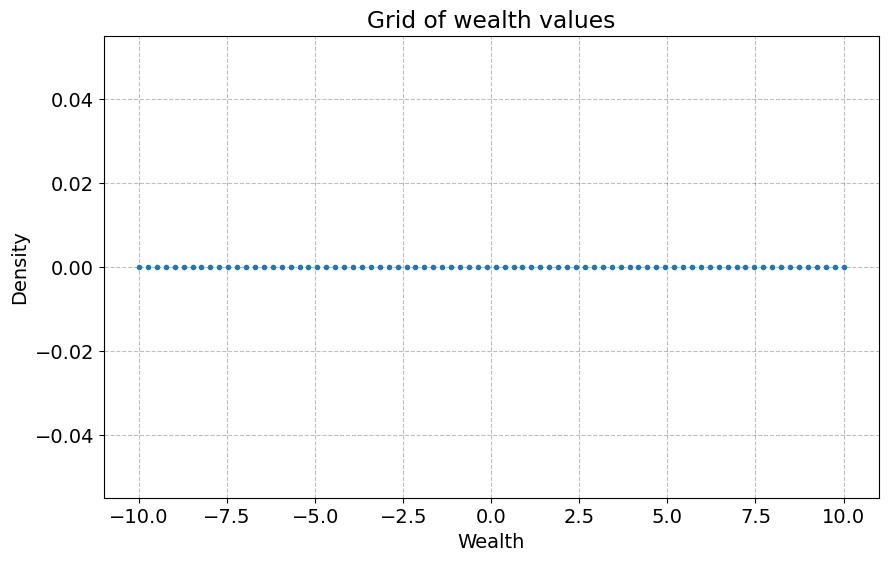

In [81]:
amin = -10.0 # lowest value of wealth
amax = 10.0 # highest value of wealth
Na = 80 # number of points in the grid

a_grid = np.linspace(amin,amax,Na) # grid of wealth values

# plot points on the grid
plt.figure(figsize=(10,6))
plt.plot(a_grid, np.zeros(Na), 'o', color=colors[0], markersize=3)
plt.title('Grid of wealth values')
plt.xlabel('Wealth')
plt.ylabel('Density')

But is this the smartest thing we can do? This has a few drawbacks:

- If most households are around the minimum wealth levels, we might want to put more points around those values 
- In % terms, the jump around small values is larger than around large values 


In [82]:
# for a rich household
print((a_grid[-1]-a_grid[-2]) / a_grid[-2])

# for a poor household
print((a_grid[40]-a_grid[41]) / a_grid[41])

0.025974025974025743
-0.6666666666666651


#### 1.1.2. <a id='toc1_1_2_'></a>[Nonlinear grid](#toc0_)

- What we can do instead, is to use a non-linear grid, that will put more points in the lower part of the grid, and less points in the upper part of the grid
- You have a lot of different flavours of this, this is just one way of doing it


In [83]:
def equilogspace(x_min,x_max,n):
    """ grid from x_min to x_max, (close to) equidistant in logs """

    pivot = np.abs(x_min) + 0.25
    grid = np.geomspace(x_min+pivot,x_max+pivot,n) - pivot
    grid[0] = x_min

    return grid

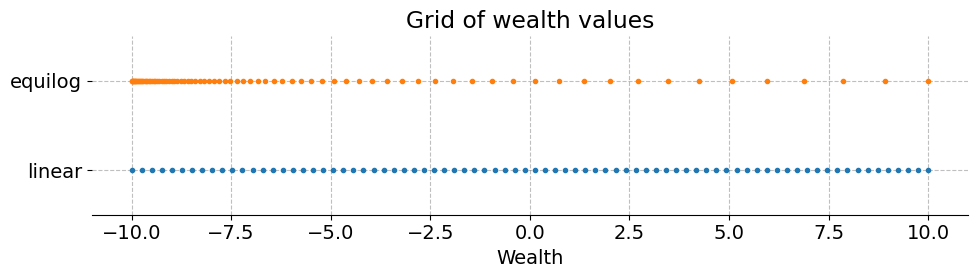

In [84]:
amin = -10.0 # lowest value of wealth
amax = 10.0 # highest value of wealth
Na = 80 # number of points in the grid

a_grid_nonlin = equilogspace(amin,amax,Na) # grid of wealth values

# plot both grids on top of each other
plt.figure(figsize=(10,3))
plt.plot(a_grid,np.zeros(Na),'o',color=colors[0],markersize=3)
plt.plot(a_grid_nonlin,np.ones(Na),'o',color=colors[1],markersize=3)
plt.yticks([0,1],['linear','equilog'])
plt.ylim(-0.5,1.5)
plt.title('Grid of wealth values')
plt.xlabel('Wealth')
plt.gca().spines[['left','right','top']].set_visible(False)
plt.tight_layout()
plt.show()

**Main takeaway:** you need to think about how you set your grids! 

Things to consider
1. **Lower bounds:** are they low enough? Are they feasible (in this case, will consumption be positive for $a=-10$?)
2. **Upper bound:** is it high enough? Will households ever reach this state?
3. **Grid size:** do I have enough resolution on my grid? Or is it too costly to have that many points?
4. **Nonlinear:** do I put my points where they matter the most?

### 1.2. <a id='toc1_2_'></a>[Interpolation](#toc0_)

- Often time, we work with functions that do not have an analytical expression. 
- For example, when we want to solve for the consumption policy function or the value function, we do not end up with a function like $c(a,z)=Ac^b+z$ 
- Instead, we obtain points on a grid. That is, for any $a^i\in a$ grid, we know the corresponding $c^i$ 
- The question is: how can we evaluate such a function outside the grid points?

$\Rightarrow$ Using linear interpolation

Main idea is simple: we draw a line between the two points we know.

If you know $y^{i}=f(x^{i})$ and $y^{i+1}=f(x^{i+1})$, then we can evaluate $f(x)$ for $x\in [x^i,x^{i+1}]$ as
$$
f(x)\approx y^i + \frac{y^{i+1}-y^i}{x^{i+1}-x^i} (x - x^i)
$$
You can also think of this as a first-order Taylor expansion around $x^i$, where the derivative is replaced by the slope between the two grid points.

Let us take an example. We know a function only at a few grid points.

In [85]:
f = lambda x: (x-3)**3 - 3*x**2 + 5*x # true function

# Assume we know the function only for those grid points
x_grid = np.linspace(-5,10,12)
y_grid = f(x_grid)

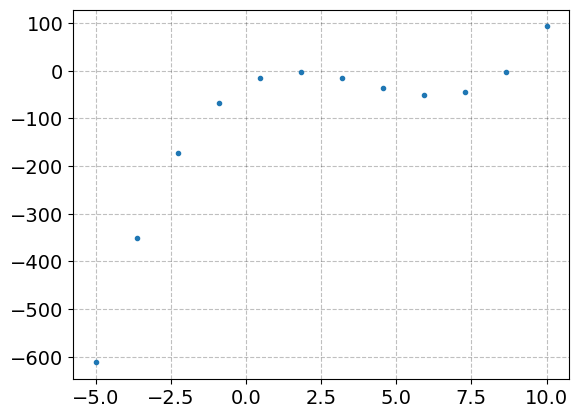

In [86]:
plt.plot(x_grid,y_grid,'o',color=colors[0],markersize=3)

We want to evaluate the function at a point between two grid points. We draw the line between the two neighbours and read off the value.

In [87]:
x_tilde = x_grid[2] + 0.5 # how can we evaluate at this point?

# simple linear interpolation
print('x below = ', x_grid[2])
print('x_tilde = ', x_tilde)
print('a above = ', x_grid[3])

diff_x = x_grid[3]-x_grid[2]
diff_y = y_grid[3]-y_grid[2]
slope = diff_y / diff_x
y_tilde_linear = y_grid[2] + slope * (x_tilde - x_grid[2])

x below =  -2.272727272727273
x_tilde =  -1.772727272727273
a above =  -0.9090909090909092


In [88]:
print("linear approximation = ", y_tilde_linear)
print("true value = ", f(x_tilde))

linear approximation =  -134.3302028549963
true value =  -127.00892186326074


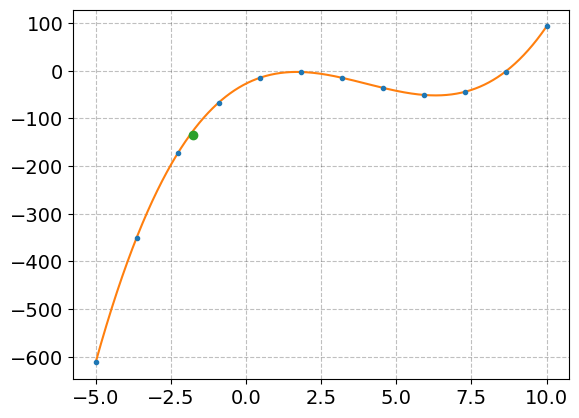

In [89]:
x_fine = np.linspace(-5,10,10000)
y_fine = f(x_fine)


plt.plot(x_fine,y_fine,color=colors[1],label='true function')
plt.plot(x_grid,y_grid,'o',color=colors[0],markersize=3)
plt.plot(x_tilde,y_tilde_linear,'o',color=colors[2],markersize=6,label='linear approximation')

The approximation is good when the function is close to linear between the two grid points, and bad when it bends a lot. More grid points where the function bends is the fix.

#### 1.2.1. <a id='toc1_2_1_'></a>[Extrapolation](#toc0_)

What can we do if we want to evaluate outside the range of our grid? We extrapolate: we continue the line through the last two points.

So if $x>x^{n-1}$ (last point on our grid), we do
$$
f(x)\approx y^{n-1} + \frac{y^{n-1}-y^{n-2}}{x^{n-1}-x^{n-2}} (x-x^{n-1})
$$
and symmetrically with $x^0$ and $x^1$ if $x<x^0$.

#### 1.2.2. <a id='toc1_2_2_'></a>[A general function](#toc0_)

Now put the two steps in one function: find the right segment, then apply the formula. Outside the grid, use the first or last segment.

In [90]:
def linear_interpolate(x_grid,y_grid,x):
    """ linear interpolation (and extrapolation)

    Args:

        x_grid (np.ndarray): known points
        y_grid (np.ndarray): known values
        x (float): point to be interpolated

    Returns:

        y (float): intepolated value

    """

    assert len(x_grid) == len(y_grid)
    n = len(x_grid)

    # a. find index in known points
    if x < x_grid[1]: # exprapolation below

        i = 0

    elif x > x_grid[-2]: # extrapolation above

        i = n-2

    else: # true interpolation

        # search
        i = 0
        while x >= x_grid[i+1] and i < n-1:
            i += 1

        # check
        assert x >= x_grid[i]
        assert x < x_grid[i+1]

    # b. interpolate
    diff_x = x_grid[i+1]-x_grid[i]
    diff_y = y_grid[i+1]-y_grid[i]
    slope = diff_y/diff_x
    y = y_grid[i] + slope*(x-x_grid[i])

    return y

x = -2.3 -> true = -176.2, interpolated = -177.0
x =  4.9 -> true =  -40.7, interpolated =  -39.5
x =  7.5 -> true =  -40.1, interpolated =  -37.2
x =  9.1 -> true =   24.1, interpolated =   30.6


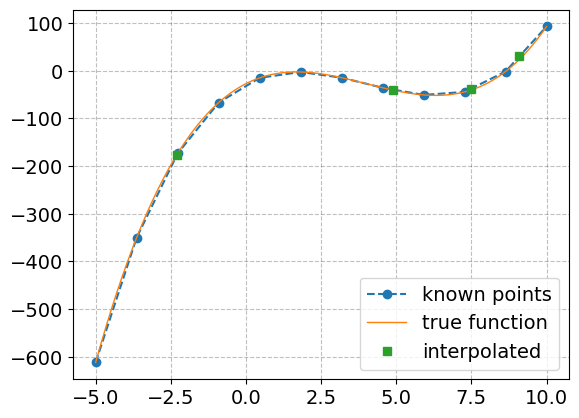

In [91]:
# interpolate
X = [-2.3,4.9,7.5,9.1]
F_approx = []
for x in X:
    true = f(x)
    y = linear_interpolate(x_grid,y_grid,x)
    F_approx.append(y)
    print(f'x = {x:4.1f} -> true = {true:6.1f}, interpolated = {y:6.1f}')

# plot
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(x_grid,y_grid,'--o',label='known points')
ax.plot(x_fine,y_fine,'-',lw=1,label='true function')
ax.plot(X,F_approx,'s',lw=1,label='interpolated')
ax.legend(loc='lower right',facecolor='white',frameon=True)
fig.savefig('figs/linear_interpolation.pdf')

In practice, we use the functions from the `consav` package, which do the same thing but are compiled with `numba`.

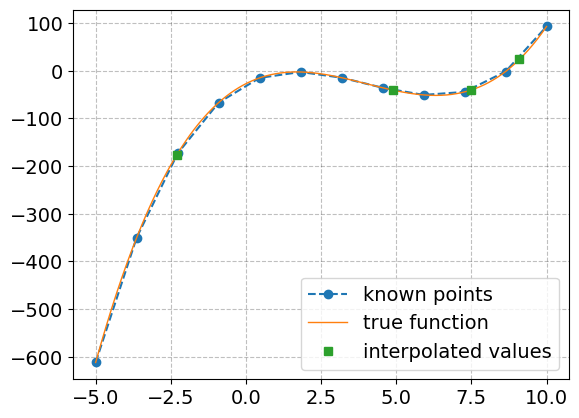

In [92]:
from consav.linear_interp import interp_1d

# b. interpolate
F_approx_consav = np.array([interp_1d(x_fine,y_fine,xi) for xi in X])

# c. plot
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(x_grid,y_grid,'--o',label='known points')
ax.plot(x_fine,y_fine,'-',lw=1,label='true function')
ax.plot(X,F_approx_consav,'s',lw=1,label='interpolated values')
ax.legend(loc='lower right',facecolor='white',frameon=True);

### 1.3. <a id='toc1_3_'></a>[Maximization](#toc0_)

In value function iteration, at every grid point we must solve
$$
\max_{c} \; u(c)+\beta v(a)
$$
There is no formula for the solution, so we need a numerical way to maximize a function.

Two methods:
- **Grid search:** try many values, keep the best. Simple and robust, but slow and imprecise.
- **Golden section search:** shrink an interval around the maximum. Fast and precise, but needs a function with a single peak.

#### 1.3.1. <a id='toc1_3_1_'></a>[A test function](#toc0_)

Take a polynomial where we know the answer:
$$
f(x) = 6x - x^3
$$
The first-order condition is $f'(x) = 6 - 3x^2 = 0$, so on $x\geq0$ the maximum is at $x^*=\sqrt{2}\approx 1.414$.

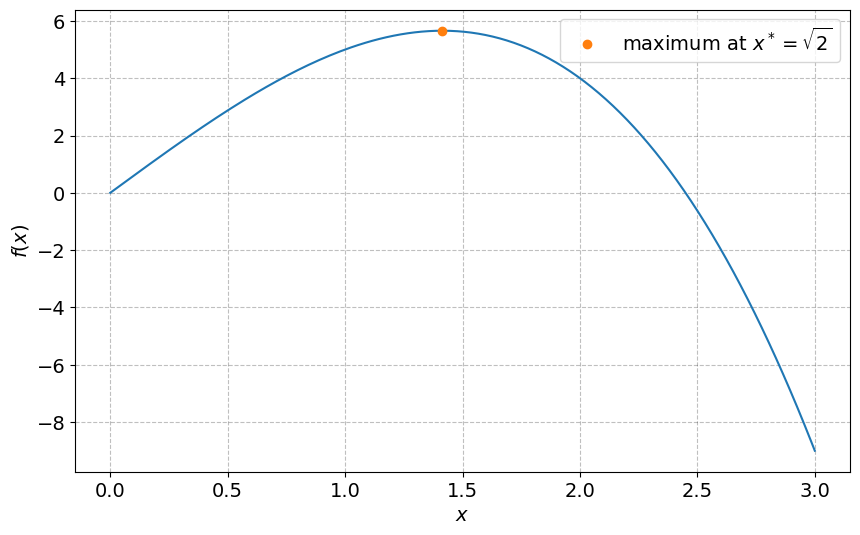

In [93]:
def f(x):
    return 6*x - x**3

x_star = np.sqrt(2)

x_plot = np.linspace(0,3,200)
plt.figure(figsize=(10,6))
plt.plot(x_plot,f(x_plot),color=colors[0])
plt.plot(x_star,f(x_star),'o',color=colors[1],label='maximum at $x^*=\\sqrt{2}$')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.show()

#### 1.3.2. <a id='toc1_3_2_'></a>[Grid search](#toc0_)

The simplest idea: evaluate $f$ on a grid of trial values and keep the best one.

##### 1.3.2.1. <a id='toc1_3_2_1_'></a>[A naive loop](#toc0_)

In [94]:
def grid_search_loop(f,x_grid):
    """ maximize f by trying every point in x_grid, plain Python loop """

    best_x = x_grid[0]
    best_f = f(x_grid[0])

    for x in x_grid:
        if f(x) > best_f:
            best_x = x
            best_f = f(x)

    return best_x

In [95]:
x_grid = np.linspace(0,3,10)
x_hat = grid_search_loop(f,x_grid)

print(f'grid search:  {x_hat:.6f}')
print(f'analytical:   {x_star:.6f}')
print(f'error:        {abs(x_hat-x_star):.6f}')
print(f'grid spacing: {x_grid[1]-x_grid[0]:.6f}')

grid search:  1.333333
analytical:   1.414214
error:        0.080880
grid spacing: 0.333333


We can only return a point that is *on* the grid, so the error is up to half the grid spacing.
More points give more precision, but every point costs one function evaluation.

In [96]:
for N in [10,100,1_000,10_000,100_000]:
    x_grid = np.linspace(0,3,N)
    x_hat = grid_search_loop(f,x_grid)
    half_spacing = (x_grid[1]-x_grid[0])/2
    print(f'N = {N:>7,}: error = {abs(x_hat-x_star):.1e}, bound = {half_spacing:.1e}')

N =      10: error = 8.1e-02, bound = 1.7e-01
N =     100: error = 1.0e-02, bound = 1.5e-02
N =   1,000: error = 2.0e-04, bound = 1.5e-03
N =  10,000: error = 1.3e-04, bound = 1.5e-04
N = 100,000: error = 5.8e-07, bound = 1.5e-05


The error is always below the bound, half the grid spacing, but how far below is luck: it depends on where $x^*$ falls between two grid points.
So ten times more points buys at most ten times more precision, at ten times the cost.
A guaranteed error of $10^{-8}$ would need about $10^{8}$ evaluations.

Before finding a smarter method, let us at least make each evaluation cheap.

##### 1.3.2.2. <a id='toc1_3_2_2_'></a>[Vectorized with numpy](#toc0_)

Python loops are slow. `numpy` evaluates $f$ on the whole array at once in compiled code, and `np.argmax` returns the position of the largest value.

In [97]:
def grid_search_numpy(f,x_grid):
    """ maximize f by trying every point in x_grid, vectorized """

    return x_grid[np.argmax(f(x_grid))]

In [98]:
x_grid = np.linspace(0,3,100_000)

print(f'loop:  {grid_search_loop(f,x_grid):.6f}')
print(f'numpy: {grid_search_numpy(f,x_grid):.6f}')

%timeit grid_search_loop(f,x_grid)
%timeit grid_search_numpy(f,x_grid)

loop:  1.414214
numpy: 1.414214
15.2 ms ± 538 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
630 μs ± 46.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


##### 1.3.2.3. <a id='toc1_3_2_3_'></a>[Compiled with numba](#toc0_)

Not everything can be vectorized. In the later notebooks, the maximization sits inside loops over grid points and time, and each step depends on the previous one.

`numba` takes a plain Python function and compiles it to machine code the first time it is called. The loop then runs as fast as compiled code.
Two rules:
1. Only use `numpy` arrays, scalars and simple loops inside the function.
2. Every function it calls must be compiled too, so we compile `f` as well.

The code is exactly the same as the naive loop, we just wrap it in `nb.njit`.

In [99]:
f_nb = nb.njit(f)
grid_search_numba = nb.njit(grid_search_loop)

# the first call compiles, so it is slow
print(f'numba: {grid_search_numba(f_nb,x_grid):.6f}')

%timeit grid_search_numba(f_nb,x_grid)

numba: 1.414214
110 μs ± 4.7 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


##### 1.3.2.4. <a id='toc1_3_2_4_'></a>[Taking stock](#toc0_)

- Grid search works for *any* function, with no assumptions.
- Its precision is the grid spacing, and its cost is one evaluation per grid point.
- `numba` makes each evaluation cheap, but does not change the trade-off.

We need a method that uses fewer evaluations.

#### 1.3.3. <a id='toc1_3_3_'></a>[Golden section search](#toc0_)

Instead of trying everything, keep an interval $[a,b]$ that contains the maximum and shrink it:

1. Pick two interior points $c<d$ and evaluate $f$ at both.
2. If $f(c)>f(d)$, the maximum cannot be to the right of $d$, so the new interval is $[a,d]$. Otherwise it is $[c,b]$.
3. Repeat until the interval is shorter than the tolerance.

Why *golden*? If the interior points sit at $61.8\%$ of the interval from each end (the inverse of the golden ratio $\varphi$), one of the two old points lands exactly where a new point is needed.
So each iteration costs one new evaluation and shrinks the interval by a factor $0.618$.

The one requirement: $f$ must have a single peak on $[a,b]$ (be *unimodal*). With two humps, step 2 can throw away the wrong side.

In [100]:
@nb.njit
def golden_section_search(f,lower,upper,tol=1e-8):
    """ maximize a unimodal f on [lower,upper] """

    inv_phi = (np.sqrt(5)-1)/2

    # a. initial bracket and two interior points
    a = lower
    b = upper
    c = b - inv_phi*(b-a)
    d = a + inv_phi*(b-a)
    f_c = f(c)
    f_d = f(d)

    # b. shrink the bracket until it is smaller than tol
    while b-a > tol:

        if f_c > f_d:

            # i. maximum is in [a,d]: old c becomes the new d
            b = d
            d = c
            f_d = f_c
            c = b - inv_phi*(b-a)
            f_c = f(c)

        else:

            # ii. maximum is in [c,b]: old d becomes the new c
            a = c
            c = d
            f_c = f_d
            d = a + inv_phi*(b-a)
            f_d = f(d)

    return (a+b)/2

In [101]:
x_hat = golden_section_search(f_nb,0.0,3.0)

print(f'golden section: {x_hat:.10f}')
print(f'analytical:     {x_star:.10f}')
print(f'error:          {abs(x_hat-x_star):.1e}')

golden section: 1.4142135768
analytical:     1.4142135624
error:          1.4e-08


After $n$ iterations the interval has width $0.618^n\,(b-a)$. Solving $0.618^n \cdot 3 = 10^{-8}$ gives the number of evaluations needed.

In [102]:
inv_phi = (np.sqrt(5)-1)/2
n_iter = np.log(1e-8/3)/np.log(inv_phi)
print(f'evaluations needed: {n_iter:.0f}')

%timeit golden_section_search(f_nb,0.0,3.0)

evaluations needed: 41
2.53 μs ± 239 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


About 40 evaluations against $10^8$ for grid search, for the same precision.
This is the method we use inside value function iteration.

In part 2 and in the next notebooks we call `optimizer` from `consav.golden_section_search`, which is this algorithm compiled with `numba`.
One trap: it *minimizes*, so we hand it minus the value.

## 2. <a id='toc2_'></a>[Solving the permanent income model with VFI](#toc0_)

This part solves the deterministic consumption-saving problem with value function iteration (VFI), and checks the answer against the closed-form solution.

Two parts:
1. **Finite horizon**: solve backwards from the last period of life (*backward induction*).
2. **Infinite horizon**: keep stepping backwards until the value function stops changing.

From this notebook on we use the compiled tools from `consav` (`equilogspace`, `interp_1d`, `optimizer`) instead of the plain `numpy` versions we built in part 1, and we `numba`-compile the solver itself, written as simple loops over the asset grid.

### 2.1. <a id='toc2_1_'></a>[The model](#toc0_)

The household solves

$$
\begin{aligned}
v_0 &= \max_{\{c_t\}_{t=0}^{T-1}} \sum_{t=0}^{T-1}\beta^t \frac{c_t^{1-\sigma}}{1-\sigma} \\
&\text{s.t.} \\
a_t &= (1+r)a_{t-1} + y_t - c_t \\
a_t &\geq \underline{a}, \quad a_{T-1} = 0
\end{aligned}
$$

Income $y_t \equiv wz_t$ is a *known sequence* (the slides write it $wz_t$), so there is no risk and the only state variable is $a_{t-1}$.

We hold the parameters in a small class, so they travel together and the grid lives next to the values that define it.
We take a household with a falling income profile, saving for retirement.

In [103]:
class Parameters:
    def __init__(self):
        # preferences
        self.beta = 0.99
        self.sigma = 2.0

        # income and interest rate
        self.r = 0.02
        self.y = np.array([1.5,1.0,0.5,0.25,0.25])

        # grids
        self.T = 5
        self.Na = 200
        self.a_min = 0.0
        self.a_max = 5.0
        self.a_grid = equilogspace(self.a_min,self.a_max,self.Na)

par = Parameters()

### 2.2. <a id='toc2_2_'></a>[The closed-form solution](#toc0_)

Before solving anything numerically, let us write down the answer.

The Euler-equation gives $c_t = (\beta R)^{t/\sigma}c_0$ with $R \equiv 1+r$.
Substituting this into the intertemporal budget constraint $\sum_t R^{-t}c_t = s_0 + h_0$ and solving for $c_0$,

$$
c_0^{\ast} = \frac{1-\kappa}{1-\kappa^T}(s_0+h_0),
\qquad \kappa \equiv \frac{(\beta R)^{1/\sigma}}{R},
\qquad s_0 \equiv Ra_{-1},
\qquad h_0 \equiv \sum_{t=0}^{T-1}R^{-t}y_t
$$

Note that this holds *only* if the borrowing constraint never binds.
We will check that it does not.

In [104]:
R = 1+par.r

kappa = (par.beta*R)**(1/par.sigma)/R
MPC = (1-kappa)/(1-kappa**par.T) # the marginal propensity to consume out of total resources
h0 = np.sum(par.y/R**np.arange(par.T)) # human capital, the present value of the income path

c0_closed = MPC*(R*par.a_grid + h0)

print(f'{kappa = :.6f}')
print(f'{MPC = :.6f}')
print(f'{h0 = :.6f}')

kappa = 0.985184
MPC = 0.206015
h0 = 3.427518


### 2.3. <a id='toc2_3_'></a>[Finite horizon: backward induction](#toc0_)

Our goal is the policy function $c_t(a_{t-1})$ for each point on the grid `a_grid` and each period $t$.
We write the problem recursively,

$$
v_t(a_{t-1}) = \max_{c_t} \frac{c_t^{1-\sigma}}{1-\sigma} + \beta v_{t+1}(a_t),
\qquad a_t = (1+r)a_{t-1}+y_t-c_t \geq \underline{a}
$$

and solve it backwards from the last period.

We start at the end.
In the last period there is no tomorrow, so the household consumes everything it has, $c_{T-1} = (1+r)a_{T-2}+y_{T-1}$.

In [105]:
c = np.zeros((par.T,par.Na))
a = np.zeros((par.T,par.Na))
v = np.zeros((par.T,par.Na))

t = par.T-1

c[t] = (1+par.r)*par.a_grid + par.y[t] # consume everything
a[t] = 0.0
v[t] = c[t]**(1-par.sigma)/(1-par.sigma)

Now step back one period.
Take a *single* point on the asset grid, say `i_a_lag = 100`, and ask what the household would get from each possible choice of $c_t$.

The choice has to leave the household with at least $\underline{a}$, so $c_t$ can be anything between $0$ and the cash-on-hand $m = (1+r)a_{t-1}+y_t$ minus $\underline{a}$.

In [106]:
t = par.T-2
i_a_lag = 100

a_lag = par.a_grid[i_a_lag]
m = (1+par.r)*a_lag + par.y[t] # cash-on-hand
c_max = m - par.a_min

print(f'wealth entering the period: {a_lag:.4f}')
print(f'income this period:         {par.y[t]:.4f}')
print(f'largest feasible c:         {c_max:.4f}')

wealth entering the period: 0.9044
income this period:         0.2500
largest feasible c:         1.1725


Note that $v_{t+1}$ is only known *on the grid*, so to evaluate the continuation value at $a_t = m-c_t$ we have to interpolate.
This is the job of `interp_1d` from `consav`, the compiled version of the linear interpolation we built in part 1 (`interp_1d_vec` is the same thing for a whole array of points, writing the result into the array we pass last).

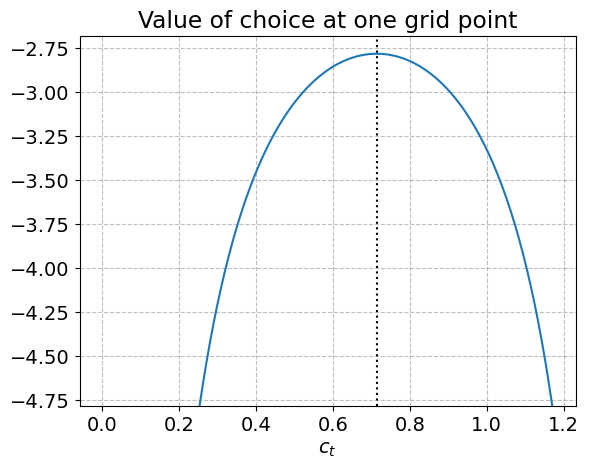

best c on this trial grid: 0.714786


In [107]:
c_trials = np.linspace(1e-8,c_max,1_000)

utility = c_trials**(1-par.sigma)/(1-par.sigma)
continuation = np.empty(c_trials.size)
interp_1d_vec(par.a_grid,v[t+1],m-c_trials,continuation)
value = utility + par.beta*continuation

plt.plot(c_trials,value)
plt.axvline(c_trials[np.argmax(value)],linestyle=':',color='black')
plt.ylim(np.max(value)-2,np.max(value)+0.1)
plt.title('Value of choice at one grid point')
plt.xlabel('$c_t$')
plt.show()

print(f'best c on this trial grid: {c_trials[np.argmax(value)]:.6f}')

The function is concave and has an interior maximum.

Let us write the objective as a function so we can hand it to `optimizer` from `consav`.
Two things to note:
1. It is `numba`-compiled with `@nb.njit`, so it can be called from inside a compiled solver later.
2. And `optimizer` *minimizes*, so it returns the *negative* of the value.

In [108]:
@nb.njit
def value_of_choice(c,m,beta,sigma,a_grid,v_plus):
    """ negative of the value of consuming c out of cash-on-hand m """

    # a. end-of-period assets implied by the choice
    a = m - c

    # b. utility today plus discounted continuation value
    utility = c**(1-sigma)/(1-sigma)
    continuation = interp_1d(a_grid,v_plus,a)

    return -(utility + beta*continuation)

In [109]:
c_star = optimizer(value_of_choice,1e-8,c_max,args=(m,par.beta,par.sigma,par.a_grid,v[t+1]),tol=1e-10)

print(f'grid search:    {c_trials[np.argmax(value)]:.8f}   (1,000 evaluations)')
print(f'golden section: {c_star:.8f}   (~50 evaluations)')
print(f'spacing of the trial grid: {c_trials[1]-c_trials[0]:.8f}')

grid search:    0.71478557   (1,000 evaluations)
golden section: 0.71498572   (~50 evaluations)
spacing of the trial grid: 0.00117370


So far we have solved *one* grid point.
We now put everything in one function and loop over the whole grid, backwards over time.

Algorithm:
Set $v_T(\cdot)=0$. Then for $t=T-1,T-2,\dots,0$ and each grid point $a_{t-1}$:
1. If $t=T-1$, consume everything: $c_t = m = (1+r)a_{t-1}+y_t$
2. Otherwise maximize $u(c_t)+\beta v_{t+1}(m-c_t)$, with $v_{t+1}$ interpolated off the grid, over $c_t\in[0,m-\underline{a}]$ with golden section search
3. Store $a_t = m-c_t$ and the value attained

The whole function is `numba`-compiled, so the plain Python loop over grid points costs nothing.
The outputs are written *into* the arrays `c`, `a` and `v` that we pass in, rather than returned; this is the convention `GEModelTools` uses later in the course.

In [110]:
@nb.njit
def solve_backwards(beta,sigma,r,a_min,y,a_grid,c,a,v):
    """ solve the finite-horizon problem backwards from the last period """

    T,Na = c.shape

    for t in range(T-1,-1,-1):
        for i_a_lag in range(Na):

            # i. cash-on-hand and maximum consumption
            m = (1+r)*a_grid[i_a_lag] + y[t]
            c_max = m - a_min

            # ii. consume everything in the last period, otherwise optimize
            if t == T-1:
                c[t,i_a_lag] = m
            else:
                c[t,i_a_lag] = optimizer(value_of_choice,1e-8,c_max,
                    args=(m,beta,sigma,a_grid,v[t+1]),tol=1e-10)

            # iii. save and store the value attained
            a[t,i_a_lag] = m - c[t,i_a_lag]
            v[t,i_a_lag] = c[t,i_a_lag]**(1-sigma)/(1-sigma)
            if t < T-1:
                v[t,i_a_lag] += beta*interp_1d(a_grid,v[t+1],a[t,i_a_lag])

In [111]:
c = np.zeros((par.T,par.Na))
a = np.zeros((par.T,par.Na))
v = np.zeros((par.T,par.Na))

t0 = time.time()
solve_backwards(par.beta,par.sigma,par.r,par.a_min,par.y,par.a_grid,c,a,v)
print(f'solved in {time.time()-t0:.2f} seconds')

solved in 0.09 seconds


### 2.4. <a id='toc2_4_'></a>[Does it work?](#toc0_)

Now compare the numerical solution with the closed form.

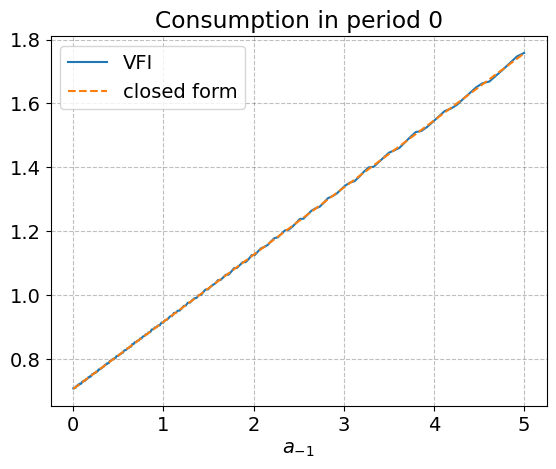

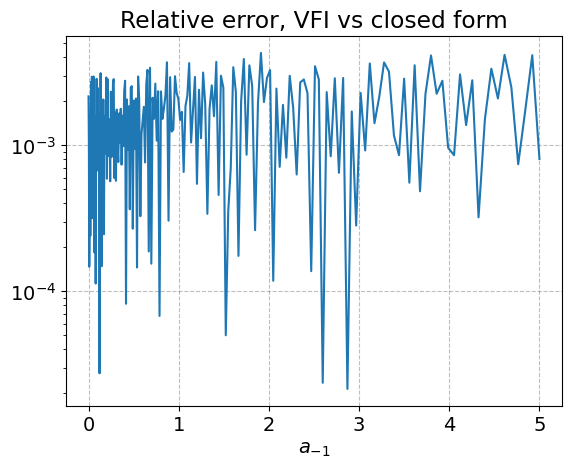

maximum relative error: 4.29e-03


In [112]:
plt.plot(par.a_grid,c[0],label='VFI')
plt.plot(par.a_grid,c0_closed,linestyle='--',label='closed form')
plt.title('Consumption in period 0')
plt.xlabel('$a_{-1}$')
plt.legend()
plt.savefig('figs/pih_vfi_vs_closed.pdf')
plt.show()

plt.plot(par.a_grid,np.abs(c[0]/c0_closed-1))
plt.yscale('log')
plt.title('Relative error, VFI vs closed form')
plt.xlabel('$a_{-1}$')
plt.savefig('figs/pih_vfi_error.pdf')
plt.show()

print(f'maximum relative error: {np.max(np.abs(c[0]/c0_closed-1)):.2e}')

### 2.5. <a id='toc2_5_'></a>[Simulating a household](#toc0_)

The policy functions tell us what a household *would* do in any state.
A *simulation* follows one household over time: run the budget constraint forward, reading consumption off the policy function each period.
Go back to the finite-horizon household of part 1, and start it with zero wealth.

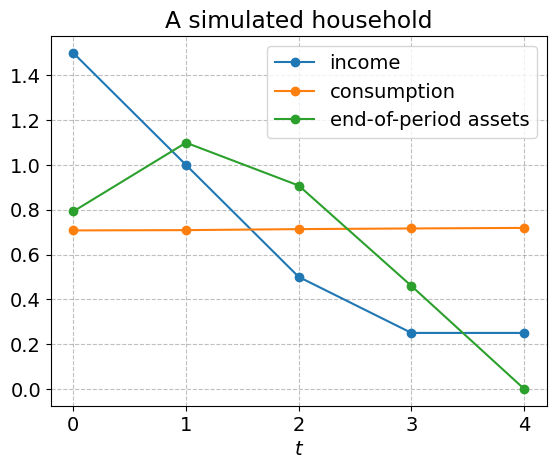

In [113]:
a_lag = 0.0
c_sim = np.zeros(par.T)
a_sim = np.zeros(par.T)

for t in range(par.T):
    c_sim[t] = interp_1d(par.a_grid,c[t],a_lag)
    a_sim[t] = (1+par.r)*a_lag + par.y[t] - c_sim[t]
    a_lag = a_sim[t]

plt.plot(par.y,'-o',label='income')
plt.plot(c_sim,'-o',label='consumption')
plt.plot(a_sim,'-o',label='end-of-period assets')
plt.xticks(range(par.T))
plt.title('A simulated household')
plt.xlabel('$t$')
plt.legend()
plt.savefig('figs/pih_simulation.pdf')
plt.show()

### 2.6. <a id='toc2_6_'></a>[Exercise: the infinite horizon](#toc0_)

Now let $T \rightarrow \infty$, with a constant income $y_t = 1$.
No period is special any more, so the value function loses its time subscript: the problem is *stationary*,

$$
v(a_{-1}) = \max_{c} \frac{c^{1-\sigma}}{1-\sigma} + \beta v(a),
\qquad a = (1+r)a_{-1}+y-c \geq \underline{a}
$$


**Exercise: implement value function iteration.**

Write two functions:

1. `vfi_step`: one backward sweep over the asset grid. It is the inner loop of `solve_backwards` for a single period: take the continuation value `v_plus` as input and write the results into `v`, `c` and `a`.
2. `solve_vfi_ss`: start from a guess for `v_plus`, call `vfi_step` repeatedly, and stop when the largest change in `v` is below `tol`. Return the policy functions, the value function and the list of errors.

Hints:
- After each step, copy `v` into `v_plus` before the next one.
- Keep `beta` and `y` as arguments rather than reading them from `par`: the infinite-horizon problem uses $\beta = 1/(1+r)$ and $y = 1$.
- Bound consumption *below* by $m-\bar{a}$ as well, so the household cannot save past the top of the grid. Otherwise the optimizer compares against extrapolated values of `v_plus`.

Then check your solution:

- compare the consumption function with the annuity rule $ra_{-1}+y$,
- compute the MPC as the slope of the consumption function and compare it with $r/(1+r)$.

In [114]:
@nb.njit
def vfi_step(beta,sigma,r,a_min,a_max,y,a_grid,v_plus,v,c,a):
    """ one backward step of value function iteration """

    for i_a_lag in range(a_grid.size):

        # i. cash-on-hand and the bounds on consumption

        # ii. optimize

        # iii. save

        pass

In [115]:
def solve_vfi_ss(par,beta,y,max_iter=20_000,tol=1e-8):
    """ solve the infinite-horizon problem by iterating the backward step """

    c = np.zeros(par.Na)
    a = np.zeros(par.Na)
    v = np.zeros(par.Na)
    errors = []

    # a. initial guess

    # b. iterate

    return c,a,v,errors

In [116]:
beta_ss = 1/(1+par.r) # beta*R = 1
y_ss = 1.0

# solve, compare with the annuity rule, compute the MPC


### 2.7. <a id='toc2_7_'></a>[Answers](#toc0_)

In [117]:
@nb.njit
def vfi_step(beta,sigma,r,a_min,a_max,y,a_grid,v_plus,v,c,a):
    """ one backward step of value function iteration """

    for i_a_lag in range(a_grid.size):

        # i. cash-on-hand and the bounds on consumption
        m = (1+r)*a_grid[i_a_lag] + y
        c_max = m - a_min
        c_min = max(1e-8,m-a_max) # never save past the top of the grid

        # ii. optimize
        c[i_a_lag] = optimizer(value_of_choice,c_min,c_max,
            args=(m,beta,sigma,a_grid,v_plus),tol=1e-10)

        # iii. save
        a[i_a_lag] = m - c[i_a_lag]
        v[i_a_lag] = -value_of_choice(c[i_a_lag],m,beta,sigma,a_grid,v_plus)

In [118]:
def solve_vfi_ss(par,beta,y,max_iter=20_000,tol=1e-8):
    """ solve the infinite-horizon problem by iterating the backward step """

    c = np.zeros(par.Na)
    a = np.zeros(par.Na)
    v = np.zeros(par.Na)

    # a. initial guess: the last period of life, consume everything
    v_plus = ((1+par.r)*par.a_grid + y)**(1-par.sigma)/(1-par.sigma)

    errors = []

    # b. iterate
    for it in range(max_iter):

        vfi_step(beta,par.sigma,par.r,par.a_min,par.a_max,y,par.a_grid,v_plus,v,c,a)

        error = np.max(np.abs(v-v_plus))
        errors.append(error)
        if error < tol: break

        v_plus[:] = v

    return c,a,v,errors

In [119]:
beta_ss = 1/(1+par.r) # beta*R = 1
y_ss = 1.0

t0 = time.time()
c_ss,a_ss,v_ss,errors = solve_vfi_ss(par,beta_ss,y_ss)

print(f'converged in {len(errors)} iterations and {time.time()-t0:.2f} seconds')

converged in 931 iterations and 0.35 seconds


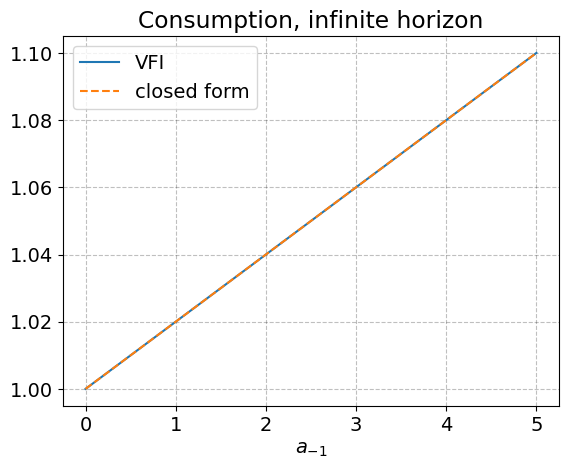

maximum relative error: 1.52e-10
MPC out of a windfall:  0.0196
PIH benchmark, r/(1+r): 0.0196


In [120]:
c_closed_ss = par.r*par.a_grid + y_ss

plt.plot(par.a_grid,c_ss,label='VFI')
plt.plot(par.a_grid,c_closed_ss,linestyle='--',label='closed form')
plt.title('Consumption, infinite horizon')
plt.xlabel('$a_{-1}$')
plt.legend()
plt.show()

MPC_ss = np.mean(np.diff(c_ss)/((1+par.r)*np.diff(par.a_grid)))

print(f'maximum relative error: {np.max(np.abs(c_ss/c_closed_ss-1)):.2e}')
print(f'MPC out of a windfall:  {MPC_ss:.4f}')
print(f'PIH benchmark, r/(1+r): {par.r/(1+par.r):.4f}')

The MPC is the share of a small windfall that is spent.
A windfall of $x$ raises cash-on-hand, so it is worth $x/(1+r)$ in beginning-of-period wealth.

The consumption function is a straight line, so the MPC is the same at every wealth level: $r/(1+r)$, rich or poor.
This is the sharpest way to see what the model gets wrong about the data, where poor households spend a much larger share of a windfall than rich ones.

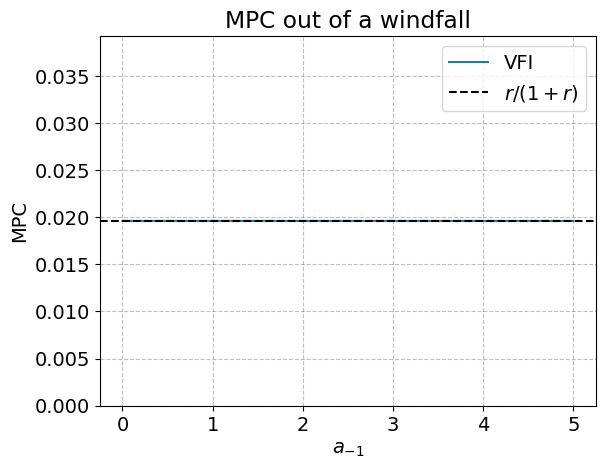

In [121]:
windfall = 0.01

c_windfall = np.empty(par.Na)
interp_1d_vec(par.a_grid,c_ss,par.a_grid+windfall/(1+par.r),c_windfall)
MPC_a = (c_windfall-c_ss)/windfall

plt.plot(par.a_grid,MPC_a,label='VFI')
plt.axhline(par.r/(1+par.r),linestyle='--',color='black',label='$r/(1+r)$')
plt.ylim(0,2*par.r/(1+par.r))
plt.title('MPC out of a windfall')
plt.xlabel('$a_{-1}$')
plt.ylabel('MPC')
plt.legend()
plt.savefig('figs/pih_mpc.pdf')
plt.show()